# Working with complicated dataset

Your name: Bushra Naveed

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [3]:
import pandas as pd
import requests
from io import StringIO

# Load raw text
url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"
response = requests.get(url)
lines = response.text.splitlines()


df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications,,,,,,,,,,,,,,,"
subject acc.ver,,,,,,,,,,,,,
100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9,NaN
99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47,NaN
99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13,NaN
99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41,NaN
99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3,NaN


In [8]:

print(df.columns.tolist())


['% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start', 'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives', 'bonds', 'publications,,,,,,,,,,,,,,,']


In [9]:
import pandas as pd
import requests
from io import StringIO


url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"
response = requests.get(url)
lines = response.text.splitlines()


fields_line = next(line for line in lines if "Fields:" in line)
fields = fields_line.replace('"', '').replace('# Fields: ', '').split(', ')

data_lines = [line for line in lines if not line.startswith('#') and not line.startswith('"')]
data_str = '\n'.join(data_lines)
df = pd.read_csv(StringIO(data_str), header=None, names=fields)

df = df.drop(columns=['query acc.ver'])

df = df.set_index('subject acc.ver')

df.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications,,,,,,,,,,,,,,,"
subject acc.ver,,,,,,,,,,,,,
100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9,NaN
99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47,NaN
99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13,NaN
99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41,NaN
99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3,NaN


### Question 2
What is the average number of publications?

In [10]:

pub_col = [col for col in df.columns if col.startswith('publications')][0]
ll remain for missing)
df[pub_col] = pd.to_numeric(df[pub_col].astype(str).str.replace(',', ''), errors='coerce')

average_publications = df[pub_col].mean()

print(f"Average number of publications (ignoring missing values): {average_publications:.2f}")


Average number of publications (ignoring missing values): nan


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [15]:

df['bonds'] = pd.to_numeric(df['bonds'].astype(str).str.replace(',', ''), errors='coerce')

high_bonds_df = df[df['bonds'] > 15000]

print("subject acc.ver with more than 15,000 bonds:")
print(high_bonds_df.index.tolist())
print(df['bonds'].sort_values(ascending=False).head(10))


subject acc.ver with more than 15,000 bonds:
[]
subject acc.ver
93.060    52.0
93.375    52.0
93.060    52.0
91.824    52.0
93.060    51.0
85.489    48.0
99.057    48.0
95.912    47.0
99.686    47.0
96.226    47.0
Name: bonds, dtype: float64


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

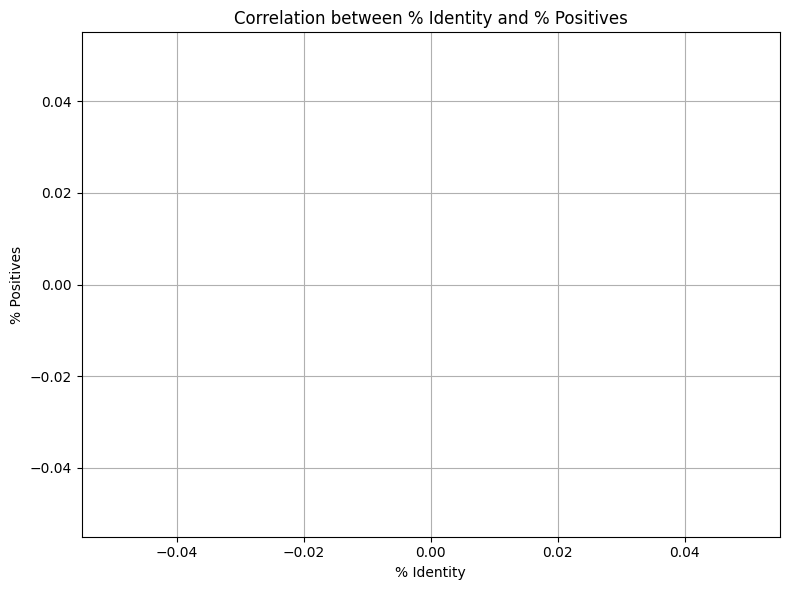

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['% identity'] = pd.to_numeric(df['% identity'], errors='coerce')
df['% positives'] = pd.to_numeric(df['% positives'], errors='coerce')


plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='% identity', y='% positives', alpha=0.7)


plt.title('Correlation between % Identity and % Positives')
plt.xlabel('% Identity')
plt.ylabel('% Positives')
plt.grid(True)
plt.tight_layout()
plt.show()


### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [17]:

protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(protein_url)

df_reset = df.reset_index()

df_reset['subject acc.ver'] = df_reset['subject acc.ver'].astype(str)

merged_df = pd.merge(df_reset, protein_df, how='left', left_on='subject acc.ver', right_on='Protein')

merged_df = merged_df.drop(columns=['Protein'])
merged_df = merged_df.set_index('subject acc.ver')

merged_df.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications,,,,,,,,,,,,,,,",Unnamed: 0,Source
subject acc.ver,,,,,,,,,,,,,,,
100.0,318,0,0,1,318,1,318,0,629,100.00,NaN,9.0,NaN,NaN,NaN
99.686,318,1,0,1,318,1,318,0,629,100.00,NaN,47.0,NaN,NaN,NaN
99.686,318,1,0,1,318,1,318,0,627,100.00,NaN,13.0,NaN,NaN,NaN
99.686,318,1,0,1,318,1,318,0,627,99.69,NaN,41.0,NaN,NaN,NaN
99.371,318,2,0,1,318,1,318,0,627,100.00,NaN,3.0,NaN,NaN,NaN
